In [1]:
%pip install numpy pandas matplotlib python-pptx

Note: you may need to restart the kernel to use updated packages.


In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import Libraries (requirements)

In [24]:
import sys  # noqa
# sys.path.append('/workspace/forecasting_simulation')  # noqa
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import seaborn as sns 
import matplotlib.colors as mcolors
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor
import pandas.plotting as pd_plotting

from utils import *


In [25]:
# Specify the folder name as 'images'
folder_path = 'image'  # Folder name 'images'
# Make sure the directory exists; if not, create it
if not os.path.exists(folder_path):
    os.makedirs(folder_path)


### Process data to return with kw

In [26]:
# client_data = load_profiles.hourly/ load_profiles.minutes
# Load your data
client_data = pd.read_csv('five_minutes.csv')

# Process the data
processed_data = process_energy_data(client_data)

# Verify the output
print(processed_data.head())

    client_name supply period            datetime        date  correct hour  \
0  digitaledge2    2023-11-30 2023-10-26 00:00:00  2023-10-26             0   
1  digitaledge2    2023-11-30 2023-10-26 00:05:00  2023-10-26             0   
2  digitaledge2    2023-11-30 2023-10-26 00:10:00  2023-10-26             0   
3  digitaledge2    2023-11-30 2023-10-26 00:15:00  2023-10-26             0   
4  digitaledge2    2023-11-30 2023-10-26 00:20:00  2023-10-26             0   

   hour  weekday      wesm    kwh      kw  
0     1        3  3.337600  39.08  468.96  
1     1        3  4.897380  39.08  468.96  
2     1        3  4.825615  39.08  468.96  
3     1        3  4.000234  39.00  468.00  
4     1        3  4.003252  39.00  468.00  


In [27]:
processed_data

,client_name,supply period,datetime,date,correct hour,hour,weekday,wesm,kwh,kw
0,digitaledge2,2023-11-30,2023-10-26 00:00:00,2023-10-26,0,1,3,3.337600,39.08,468.96
1,digitaledge2,2023-11-30,2023-10-26 00:05:00,2023-10-26,0,1,3,4.897380,39.08,468.96
2,digitaledge2,2023-11-30,2023-10-26 00:10:00,2023-10-26,0,1,3,4.825615,39.08,468.96
3,digitaledge2,2023-11-30,2023-10-26 00:15:00,2023-10-26,0,1,3,4.000234,39.00,468.00
4,digitaledge2,2023-11-30,2023-10-26 00:20:00,2023-10-26,0,1,3,4.003252,39.00,468.00
...,...,...,...,...,...,...,...,...,...,...
96763,digitaledge2,2024-09-30,2024-09-25 23:35:00,2024-09-25,23,24,2,4.759869,45.84,550.08
96764,digitaledge2,2024-09-30,2024-09-25 23:40:00,2024-09-25,23,24,2,4.753841,45.84,550.08
96765,digitaledge2,2024-09-30,2024-09-25 23:45:00,2024-09-25,23,24,2,4.749976,43.89,526.68
96766,digitaledge2,2024-09-30,2024-09-25 23:50:00,2024-09-25,23,24,2,4.638510,43.89,526.68


## Generate Energy Summary

In [28]:
# Generate energy summary (slide 1)
energy_summary = generate_energy_summary(client_data)
energy_summary

,supply period,number of hours,kwh,kw,load factor
0,2023-11-30,744.00,"371,827.20",680.40,73.45%
1,2023-12-31,720.00,"370,132.62",709.92,72.41%
2,2024-01-31,744.00,"373,162.26",761.28,65.88%
3,2024-02-29,744.00,"404,063.91",717.84,75.66%
4,2024-03-31,696.00,"380,537.25",648.24,84.34%
5,2024-04-30,744.00,"366,739.35",695.40,70.88%
6,2024-05-31,720.00,"366,741.18",645.00,78.97%
7,2024-06-30,744.00,"396,093.75",629.28,84.60%
8,2024-07-31,720.00,"359,701.77",654.12,76.38%
9,2024-08-31,744.00,"343,199.40",619.80,74.43%


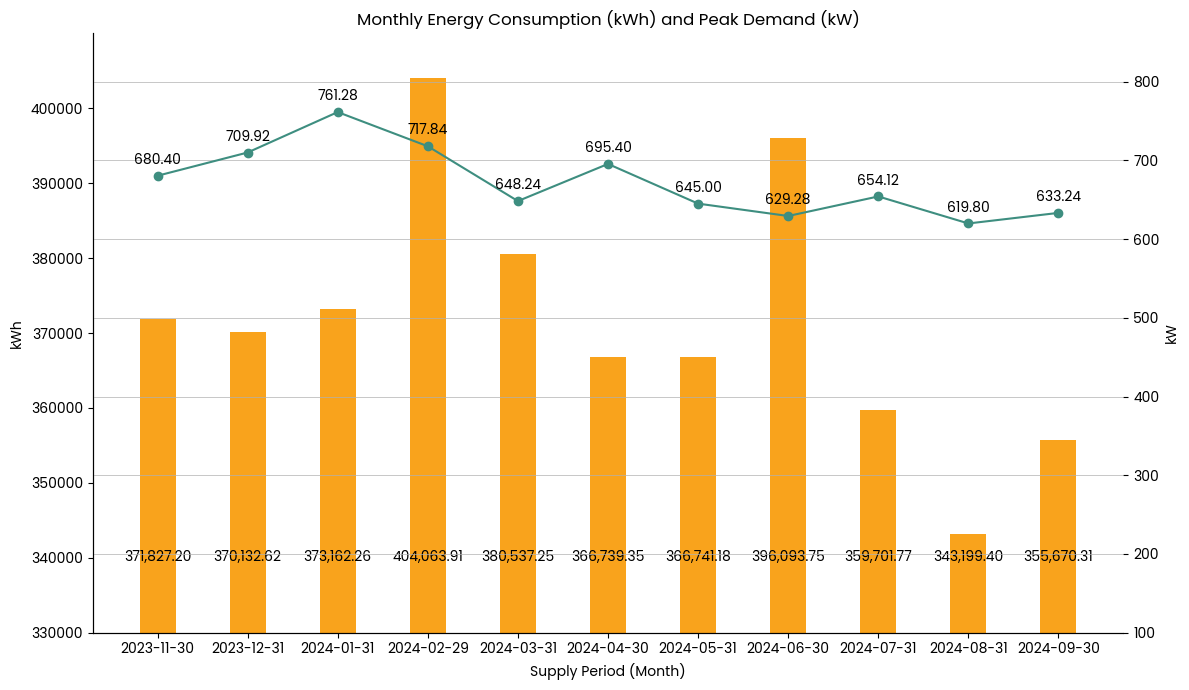

In [29]:
energy_consumption_plot(energy_summary)

## Plot Energy behavior

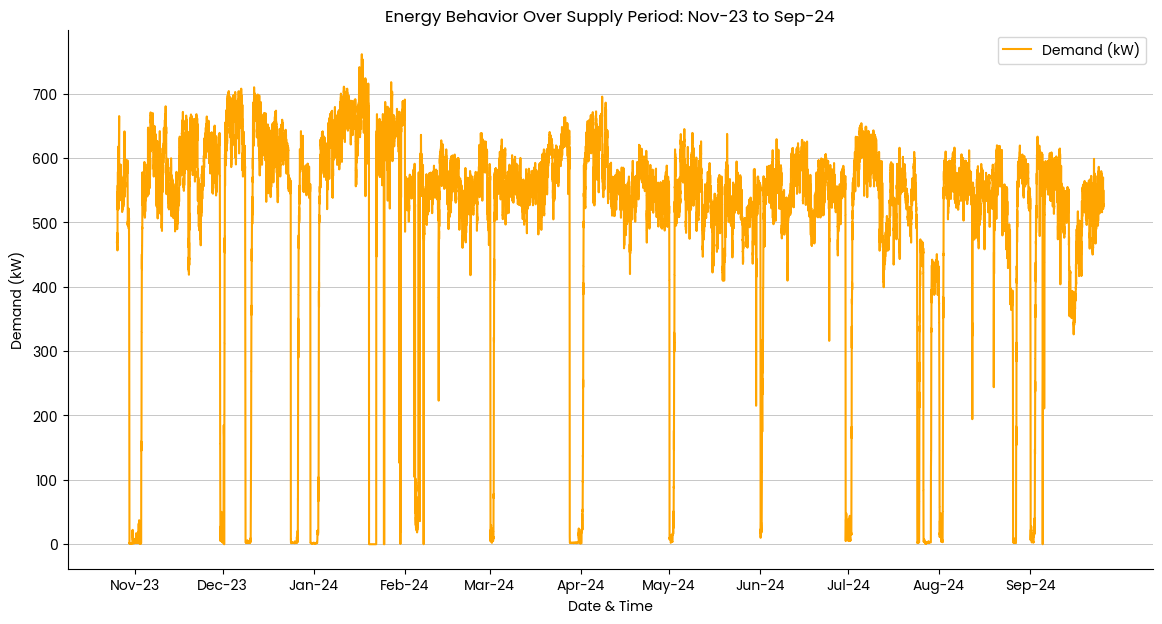

In [30]:
# Call the function to plot
energy_behavior_plot(client_data)

## Hourly Average Demand by Day

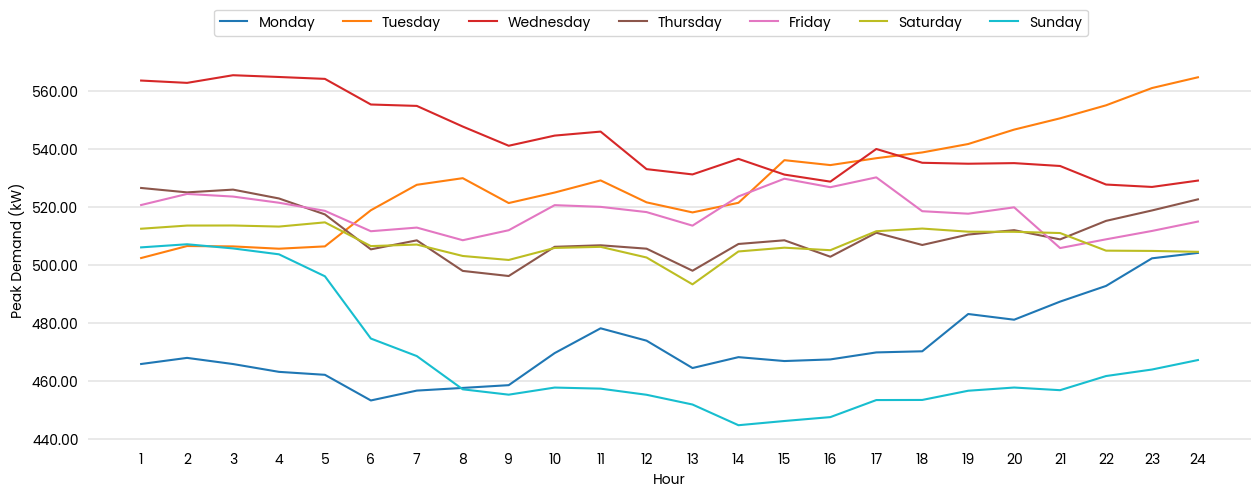

In [31]:
# Average by Hour
hourly_load_curve_by_day = client_data.pivot_table(
  index="hour",
  columns="weekday",
  values="kw",
  aggfunc={
    "kw": "mean"
  }
)
 
# Convert from kW to MW
# hourly_load_curve_by_day = hourly_load_curve_by_day / 1000
 
# Get list of days of the week
days_of_week = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
 
plot_hourly_by_day_load_curve(hourly_load_curve_by_day, column_name='max', unit='kW')

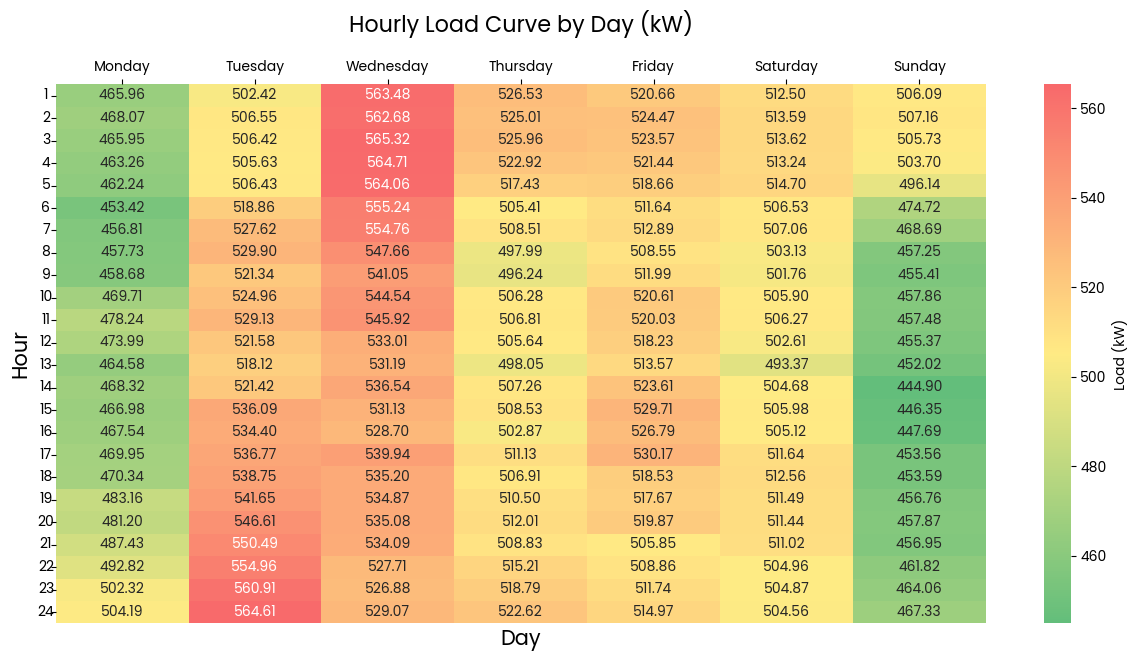

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.colors as mcolors
import os  # For directory handling

# Define the new color map based on the provided colors
cmap = mcolors.LinearSegmentedColormap.from_list(
    "", ["#63BE7B", "#FFEB84", "#F8696B"]  # Custom colors for the heatmap
)

# Define weekday labels
weekday_labels = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Specify the folder name as 'images'
folder_path = 'image'  # Folder name 'images'

# Make sure the directory exists; if not, create it
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# Display the hourly load curve by day as a heatmap table with the new color map
def display_hourly_by_day_table(hourly_by_day_summary):
    plt.figure(figsize=(15, 7))
    ax = sns.heatmap(
        hourly_by_day_summary,
        annot=True,
        fmt=".2f",
        cmap=cmap,  # Use the updated colormap
        cbar_kws={'label': 'Load (kW)'}
    )
    
    # Move x-axis labels to the top
    ax.xaxis.set_ticks_position('top')
    
    # Set custom labels for the x-axis on top with centered alignment
    ax.set_xticks(np.arange(len(weekday_labels)) + 0.5)
    ax.set_xticklabels(weekday_labels, rotation=0, ha='center')

    # Rotate y-axis (hour) labels to make them vertical
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='center')
    
    plt.xlabel("Day", fontsize=15)  # X-axis title at the top
    plt.ylabel("Hour", fontsize=15)  # Y-axis title

    plt.title("Hourly Load Curve by Day (kW)", fontsize=16, pad=20)  # Add padding to title
    
    # Save the plot as an image in the 'images' folder
    image_path = os.path.join(folder_path, 'hourly_load_curve.png')
    plt.savefig(image_path)
    plt.show()

# Use the function to display the table as a heatmap
display_hourly_by_day_table(hourly_load_curve_by_day)

## Hourly Average Demand VS WESM

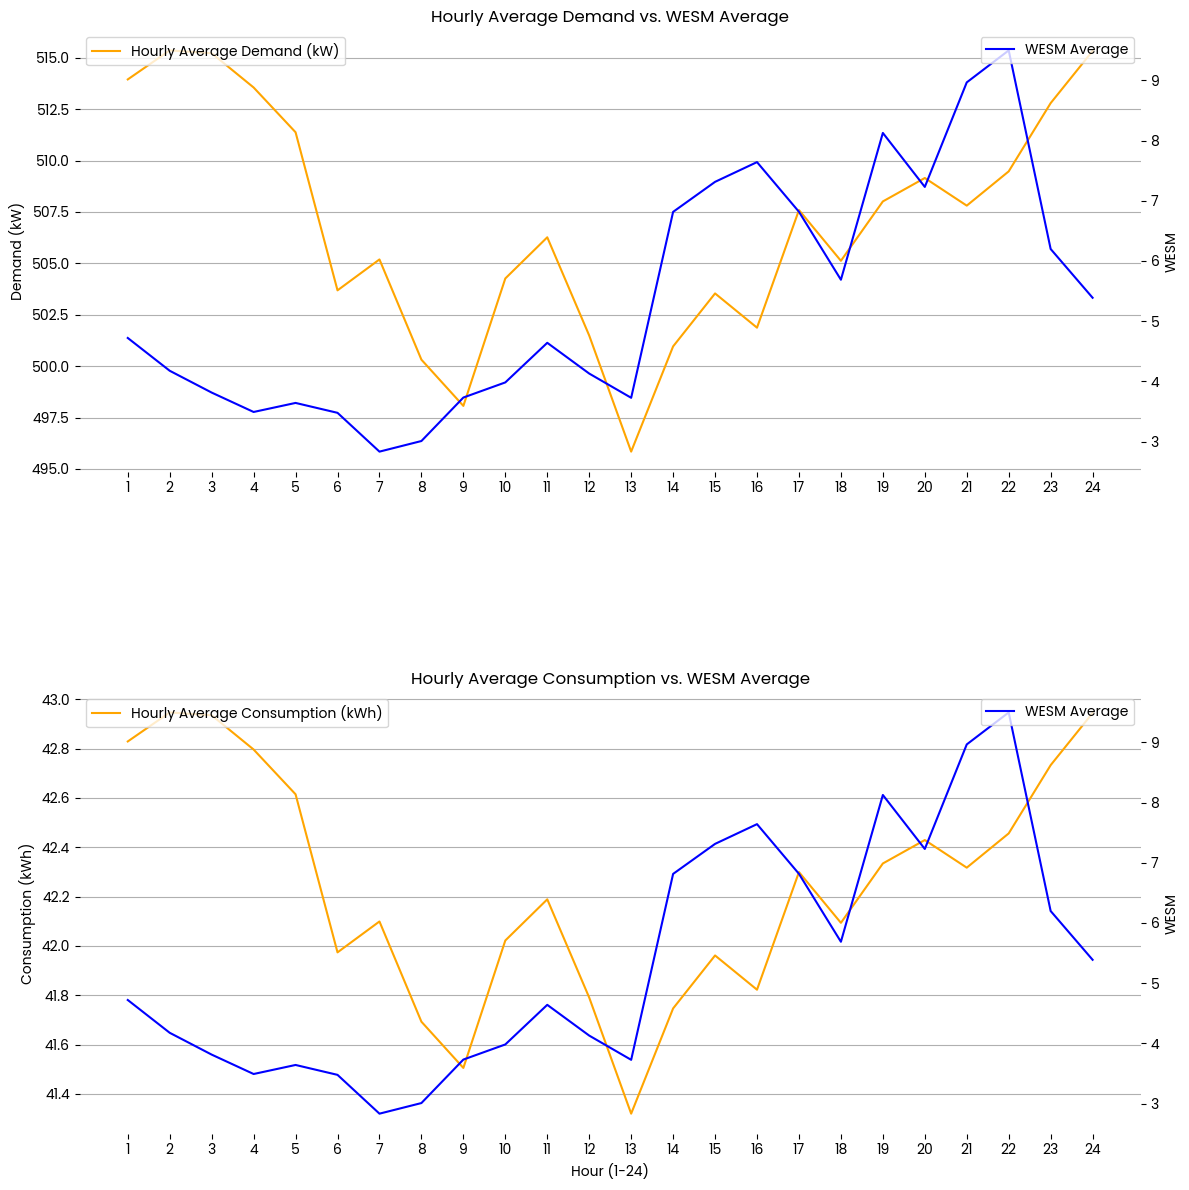

In [33]:
plot_demand_and_consumption_WESM(client_data)

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# Assuming 'data' is your original DataFrame with columns like 'hour', 'kw', 'wesm', etc.
# Define values to calculate in the pivot table
values = 'kw'  # Adjust this if you want a different column

# Calculate the daily kW report
daily_kw_report = pd.pivot_table(
    client_data,
    index='hour',
    values=values,
    aggfunc=['mean', 'max', 'min', 'sum'],
    sort=False,
    margins=True,
    margins_name='Grand Total'
).reset_index()

# Drop the extra level in the columns and convert 'hour' to string
daily_kw_report.columns = daily_kw_report.columns.droplevel(1)
daily_kw_report['hour'] = daily_kw_report['hour'].astype(str)

# Calculate the daily WESM report
daily_wesm_report = pd.pivot_table(
    client_data,
    index='hour',
    values='wesm',
    aggfunc='mean',
    sort=False,
    margins=True,
    margins_name='Grand Total'
).reset_index()
daily_wesm_report['hour'] = daily_wesm_report['hour'].astype(str)

# Calculate % of consumption
daily_kw_report['% of Consumption'] = daily_kw_report['sum'] / daily_kw_report.loc[
    daily_kw_report['hour'] == 'Grand Total', 'sum'
].values[0] * 100

# Merge the reports
daily_kw_report = daily_kw_report.merge(daily_wesm_report, on='hour', how='left')
daily_kw_report.columns = ['Hour', 'Mean', 'Max', 'Min', 'Sum', '% of Consumption', 'WESM']

# Ensure all relevant columns are numeric for the heatmap to work
numeric_columns = ['Mean', 'Max', 'Sum', '% of Consumption', 'WESM']
daily_kw_report[numeric_columns] = daily_kw_report[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Define a custom colormap for the heatmap
cmap = mcolors.LinearSegmentedColormap.from_list(
    "", ["#63BE7B", "#FFEB84", "#F8696B"]  # Custom colors for the heatmap
)

# Style the table and exclude the entire last row from the heatmap
styled_daily_kw_report = daily_kw_report.style.background_gradient(
    cmap=cmap,
    # only ['mean', 'max', 'sum', '% of consumption'] columns and all rows except last row
    subset=pd.IndexSlice[:23, ['Mean', 'Max', 'Sum', '% of Consumption', 'WESM']]
).format(
    formatter={
        'Mean': '{:,.4f}',
        'Min': '{:,.4f}',
        'Max': '{:,.4f}',
        'Sum': '{:,.4f}',
        '% of Consumption': '{:,.4f}%',
        'WESM': '{:,.4f}'
    }
)
# Display the styled table
styled_daily_kw_report

,Hour,Mean,Max,Min,Sum,% of Consumption,WESM
0,1,513.9499,690.8400,0.0000,"2,072,245.9200",4.2244%,4.7211
1,2,515.3620,704.0400,0.0000,"2,077,939.6800",4.2360%,4.1764
2,3,515.2234,698.7600,0.0000,"2,077,380.7200",4.2348%,3.8141
3,4,513.5575,701.2800,0.0000,"2,070,663.9000",4.2212%,3.4919
4,5,511.3792,705.6000,0.0000,"2,061,881.0400",4.2033%,3.6422
5,6,503.6884,696.1200,0.0000,"2,030,871.4800",4.1400%,3.4778
6,7,505.1919,709.0800,0.0000,"2,036,933.6400",4.1524%,2.8334
7,8,500.3153,710.8800,0.0000,"2,017,271.4000",4.1123%,3.0096
8,9,498.0661,752.0400,0.0000,"2,008,202.6400",4.0938%,3.7317
9,10,504.2662,761.2800,0.0000,"2,033,201.2800",4.1448%,3.9829


In [35]:
import os
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN
from pptx import Presentation
import pandas as pd

# Get the current working directory where the Jupyter notebook is running
current_dir = os.getcwd()

# Define the relative paths for images
image_folder = os.path.join(current_dir, 'image')

# Ensure the image paths are correct
image_paths = {
    'energy_consumption': os.path.join(image_folder, 'energy_consumption.png'),
    'energy_behavior': os.path.join(image_folder, 'energy_bevahior.png'),
    'hourly_load_curve': os.path.join(image_folder, 'hourly_load_curve.png'),
    'peak_demand_plot': os.path.join(image_folder, 'peak_demand_plot.png'),
    'demand_consumption_wesm': os.path.join(image_folder, 'demand_consumption_wesm.png'),
}

# Checking if images exist
for name, path in image_paths.items():
    if not os.path.exists(path):
        print(f"Image not found: {path}")
    else:
        print(f"Image found: {path}")

# Define the PowerPoint template path and output path
template_path = os.path.join(current_dir, 'solx.pptx')
output_path = os.path.join(current_dir, 'insights.pptx')

# Load the PowerPoint template
ppt = Presentation(template_path)
title_slide_layout = ppt.slide_layouts[0]  # Title slide
content_slide_layout = ppt.slide_layouts[1]  # Content slide
section_slide_layout = ppt.slide_layouts[3]  # Section slide
two_content_slide_layout = ppt.slide_layouts[4]  # Two content slide

Image found: c:\Users\MARK\Insights_Automation\image\energy_consumption.png
Image found: c:\Users\MARK\Insights_Automation\image\energy_bevahior.png
Image found: c:\Users\MARK\Insights_Automation\image\hourly_load_curve.png
Image found: c:\Users\MARK\Insights_Automation\image\peak_demand_plot.png
Image found: c:\Users\MARK\Insights_Automation\image\demand_consumption_wesm.png


In [36]:
# Function to add a table with content to a PowerPoint slide
def add_table_to_slide(slide, client_data, rows, cols, x, y, width, height):
    table = slide.shapes.add_table(rows, cols, x, y, width, height).table
    
    # Adjust column width for the first column
    table.columns[0].width = Inches(2.2)

    # Define the row header color (using RGB)
    row_header_color = RGBColor(249, 163, 28)

    # Rename the columns
    new_column_names = {
        'supply period': 'Supply Period',
        'number of hours': 'Total Hours',
        'kwh': 'Consumption(kWh)',
        'kw': 'Demand(kW)',
        'load factor': 'Load Factor'
    }
    
    # Add header with orange background and white font
    for col_idx, col_name in enumerate(client_data.columns):
        new_name = new_column_names.get(col_name.lower(), col_name)  # Get the new name if available
        cell = table.cell(0, col_idx)
        cell.text = str(new_name)
        cell.fill.solid()
        cell.fill.fore_color.rgb = RGBColor(249, 163, 28)  # Orange
        cell.text_frame.paragraphs[0].font.color.rgb = RGBColor(255, 255, 255)  # White
        cell.text_frame.paragraphs[0].font.size = Pt(12)  # Header font size
        cell.text_frame.paragraphs[0].alignment = PP_ALIGN.CENTER
    
    # Fill table with data and adjust font size for each cell
    for row_idx, row_data in enumerate(client_data.values):
        for col_idx, cell_value in enumerate(row_data):
            cell = table.cell(row_idx + 1, col_idx)  # +1 to skip the header row
            cell.text = str(cell_value)
            cell.text_frame.paragraphs[0].font.size = Pt(10)  # Font size for content
            cell.text_frame.paragraphs[0].alignment = PP_ALIGN.CENTER

        # Bold the rows for 'Total', 'Average', 'Max', 'Min'
        if row_data[0] in ['Total', 'Average', 'Max', 'Min']:
            for col_idx in range(cols):
                cell = table.cell(row_idx + 1, col_idx)
                cell.text_frame.paragraphs[0].font.bold = True  # Make the text bold

    return table

# Add a new slide with content layout
slide2 = ppt.slides.add_slide(content_slide_layout)
slide2.shapes.title.text = "Monthly kW, kWh Comparison & Load Factor​"

# Add the energy summary table to the slide
add_table_to_slide(slide2, energy_summary, rows=len(energy_summary)+1, cols=len(energy_summary.columns), 
                   x=Inches(0.4), y=Inches(2.0), width=Inches(13), height=Inches(5))

slide3 = ppt.slides.add_slide(content_slide_layout)
slide3.shapes.title.text = "Monthly Energy Consumption (kWh) and Peak Demand (kW)"
slide3.shapes.add_picture(image_paths['energy_consumption'],
                         left= Inches(0.4), top= Inches(2),
                         width= Inches(12), height= Inches(5))
# pic = slide.shapes.add_picture('energy_consumption.png', left, top, height=Inches(5.5))

#Add 
slide4 = ppt.slides.add_slide(content_slide_layout)
slide4.shapes.title.text = "Load Graph"
slide4.shapes.add_picture(image_paths['energy_behavior'],
                         left= Inches(0.4), top= Inches(2),
                         width= Inches(13), height= Inches(5))

#Add 
slide5 = ppt.slides.add_slide(content_slide_layout)
slide5.shapes.title.text = "Daily Average Demand"
slide5.shapes.add_picture(image_paths['hourly_load_curve'],
                         left= Inches(0.4), top= Inches(2),
                         width= Inches(8), height= Inches(5.2))
slide5.shapes.add_picture(image_paths['peak_demand_plot'],
                         left= Inches(7), top= Inches(2),
                         width= Inches(5), height= Inches(5.2))

# Add a new slide with content layout
slide6 = ppt.slides.add_slide(content_slide_layout)
slide6.shapes.title.text = "Hourly Averages Demand​"
slide6.shapes.add_picture(image_paths['peak_demand_plot'],
                         left= Inches(0.4), top= Inches(2),
                         width= Inches(8), height= Inches(5.2))
slide6.shapes.add_picture(image_paths['demand_consumption_wesm'],
                         left= Inches(7), top= Inches(2),
                         width= Inches(5), height= Inches(5.2))
# Save the PowerPoint
ppt.save(output_path)

